# 13 · 직접 쓴 미분을 자동미분 그래프로 연결하기

**완성할 것:** NumPy 배열을 담는 작은 `Node`를 만들고, 연산의 국소 미분을 연결해 MLP를 학습합니다. 같은 가중치에서 손으로 쓴 backward·이 엔진·PyTorch·중심차분을 비교합니다.

먼저 [01 미분](../00_기초/01_gradients_and_learning.ipynb), [03 MLP](../00_기초/03_perceptron_to_mlp.ipynb)를 연결합니다.
핵심 코드는 모두 본문에 있습니다. [그림 보조 코드](../../src/utils/bridge_plots.py), [전체 경로](../../docs/CURRICULUM.md).

이 단원의 PyTorch 비교 셀은 CPU의 `float64`를 사용합니다. 프로젝트 최상위에서 `python -m pip install -e '.[dev,framework]'`로 실행 환경을 준비할 수 있습니다.

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/utils/plotting.py').is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
import torch
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils.bridge_plots import plot_curves, plot_clouds, plot_matrices
setup_plots()
print('NumPy:', np.__version__, 'PyTorch:', torch.__version__, '비교 장치: CPU, dtype: float64')

NumPy: 2.3.5 PyTorch: 2.11.0+cu130 비교 장치: CPU, dtype: float64


## 1. 자동미분이 연결하는 것은 국소 변화율입니다

계산 $u=x^2$, $y=u+u$에서 $dy/du=2$, $du/dx=2x$이므로 $dy/dx=4x$입니다.
$x=3$이면 $u=9$, $y=18$, $dy/dx=12$입니다. 같은 $u$를 두 경로에서 사용했으므로 그 지점의 기울기는 두 기여의 **합**입니다.

일반적으로 $y=f(x)$가 벡터일 때 $J_{ij}=\partial y_i/\partial x_j$를 Jacobian이라 합니다.
뒤에서 $g_i=\partial L/\partial y_i$가 오면

$$\frac{\partial L}{\partial x_j}=\sum_i g_iJ_{ij},\qquad d x=J^Tg.$$

이를 **VJP(vector–Jacobian product)** 라고 부릅니다. 열벡터 규약의 $J^Tg$는 행벡터 규약에서 $g^TJ$입니다.
전체 Jacobian을 저장하는 대신 연산마다 이 곱을 계산합니다. 스칼라 손실은 시작값 $dL/dL=1$을 사용하고, 벡터 출력은 목적을 정하는 가중치 $g$를 전달합니다.

In [2]:
# 작은 Jacobian을 실제로 써서 VJP와 내적 목적의 미분을 비교합니다.
x_hand = np.array([2., 3.])
J_hand = np.array([[x_hand[1], x_hand[0]], [1., 2*x_hand[1]]])  # y=(x0*x1, x0+x1**2)
g_hand = np.array([.5, -2.])
vjp_hand = J_hand.T @ g_hand
np.testing.assert_allclose(vjp_hand, [-.5, -11.])
print('J.T @ g:', vjp_hand)

J.T @ g: [ -0.5 -11. ]


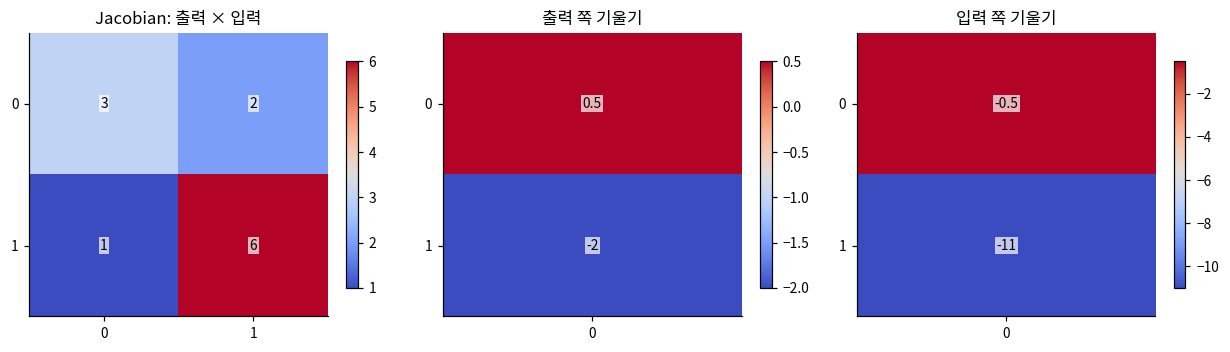

In [3]:
plot_matrices([J_hand, g_hand[:, None], vjp_hand[:, None]], ['Jacobian: 출력 × 입력', '출력 쪽 기울기', '입력 쪽 기울기'])

## 2. broadcasting의 역방향은 합치기입니다

$Y=X+b$에서 $X:(N,D)$, $b:(D,)$이면 $b_j$가 $N$번 쓰입니다.
따라서 $db_j=\sum_n dY_{nj}$입니다. `(N,1)`을 `(N,D)`로 확장했다면 열을 합해야 합니다.
앞에 추가된 축을 합하고, 원래 길이가 1이었던 축을 길이 1로 남기며 합하면 원래 shape의 기울기를 얻습니다.
`keepdims=True`는 합한 축의 길이를 1로 유지합니다.

In [4]:
def sum_to_shape(gradient, original_shape):
    g = np.asarray(gradient)
    while g.ndim > len(original_shape):
        g = g.sum(axis=0)
    for axis, size in enumerate(original_shape):
        if size == 1:
            g = g.sum(axis=axis, keepdims=True)
    return g.reshape(original_shape)

In [5]:
upstream = np.arange(1., 7.).reshape(2, 3)
np.testing.assert_allclose(sum_to_shape(upstream, (3,)), [5., 7., 9.])
np.testing.assert_allclose(sum_to_shape(upstream, (2, 1)), [[6.], [15.]])
np.testing.assert_allclose(sum_to_shape(upstream, ()), 21.)
print('broadcast 역방향: 열별 / 행별 / 전체 합 검산')

broadcast 역방향: 열별 / 행별 / 전체 합 검산


## 3. Node: 값·부모·국소 backward 보관하기

`Node.data`는 순전파 값, `Node.grad`는 그 값에 대한 손실의 기울기입니다. `parents`는 입력 Node들의 tuple이며, `pullback`은 뒤에서 온 기울기를 부모에게 더하는 함수입니다.
클래스의 `__add__`, `__mul__`, `__matmul__`은 Python이 `+`, `*`, `@`를 실행할 때 부르는 메서드입니다. 아래에서 정의할 연산 함수로 연결합니다.

**위상 순서**는 각 입력이 그 입력을 사용하는 연산보다 먼저 오는 순서입니다.
부모를 먼저 방문하고 자신을 목록에 추가한 뒤 목록을 뒤집으면 역전파 순서가 됩니다.
같은 Node는 한 번만 목록에 넣되, 모든 사용 경로의 기울기를 `+=`로 모읍니다.

이 교육용 엔진은 매 `backward` 호출마다 도달 가능한 Node의 기울기를 0으로 만들고 새로 계산합니다.
파라미터 갱신은 그 그래프의 backward가 끝난 뒤 수행하며, 다음 스텝에서 순전파 그래프를 새로 만듭니다.

In [6]:
class Node:
    def __init__(self, data, parents=(), pullback=None):
        self.data = np.array(data, dtype=float, copy=True)
        self.grad = np.zeros_like(self.data)
        self.parents = tuple(parents)
        self.pullback = pullback

    def backward(self, seed=None):
        order, visited = [], set()
        def visit(node):
            if node in visited:
                return
            visited.add(node)
            for parent in node.parents:
                visit(parent)
            order.append(node)
        visit(self)
        if seed is None:
            if self.data.shape != ():
                raise ValueError('벡터 출력에는 같은 shape의 seed를 전달합니다.')
            seed = np.ones_like(self.data)
        seed = np.asarray(seed, dtype=float)
        if seed.shape != self.data.shape:
            raise ValueError('seed와 출력의 shape를 맞춥니다.')
        for node in order:
            node.grad = np.zeros_like(node.data)
        self.grad = seed.copy()
        for node in reversed(order):
            if node.pullback is not None:
                node.pullback(node.grad)

    def __add__(self, other):
        return add(self, other)

    def __radd__(self, other):
        return add(other, self)

    def __mul__(self, other):
        return multiply(self, other)

    def __rmul__(self, other):
        return multiply(other, self)

    def __neg__(self):
        return multiply(self, -1.)

    def __sub__(self, other):
        return add(self, -as_node(other))

    def __matmul__(self, other):
        return matmul(self, other)

    def tanh(self):
        return tanh(self)

    def sum(self):
        return total_sum(self)

    def mean(self):
        return total_sum(self) * (1. / self.data.size)


def as_node(value):
    return value if isinstance(value, Node) else Node(value)

### 국소 규칙을 코드로 넣기

$Y=A+B$: $dA=G$, $dB=G$, 각 원래 shape로 합칩니다.

$Y=A\odot B$: $dA=G\odot B$, $dB=G\odot A$, broadcasting 축을 합칩니다.

$Y=AB$: $dA=GB^T$, $dB=A^TG$. 이 엔진의 행렬곱은 **2차원 행렬 둘**을 사용합니다.

$Y=\tanh A$: $dA=G\odot(1-Y^2)$.

$Y=\sum A$: 입력 모든 원소에 스칼라 $G$를 전달합니다. `mean`은 전체 원소 수로 나눈 `sum`입니다.
내부 `back` 함수가 부모와 순전파 값을 기억하는 방식은 Python의 closure입니다.

In [7]:
def add(a, b):
    a, b = as_node(a), as_node(b)
    def back(g):
        a.grad += sum_to_shape(g, a.data.shape)
        b.grad += sum_to_shape(g, b.data.shape)
    return Node(a.data + b.data, (a, b), back)


def multiply(a, b):
    a, b = as_node(a), as_node(b)
    def back(g):
        a.grad += sum_to_shape(g * b.data, a.data.shape)
        b.grad += sum_to_shape(g * a.data, b.data.shape)
    return Node(a.data * b.data, (a, b), back)


def matmul(a, b):
    a, b = as_node(a), as_node(b)
    if a.data.ndim != 2 or b.data.ndim != 2:
        raise ValueError('이 matmul의 입력은 2차원 행렬 두 개입니다.')
    def back(g):
        a.grad += g @ b.data.T
        b.grad += a.data.T @ g
    return Node(a.data @ b.data, (a, b), back)


def tanh(a):
    a = as_node(a)
    value = np.tanh(a.data)
    def back(g):
        a.grad += g * (1 - value**2)
    return Node(value, (a,), back)


def total_sum(a):
    a = as_node(a)
    def back(g):
        a.grad += np.ones_like(a.data) * g
    return Node(a.data.sum(), (a,), back)

In [8]:
x = Node(3.)
u = x * x
y = u + u
y.backward()
np.testing.assert_allclose([u.data, y.data, x.grad], [9., 18., 12.])
y.backward()
np.testing.assert_allclose(x.grad, 12.)

v = Node(np.array([2., 3.]))
f = v * v + v
f.backward(np.array([.5, -2.]))
np.testing.assert_allclose(v.grad, [2.5, -14.])

row = Node(np.array([[1.], [2.]]))
column = Node(np.array([3., 4., 5.]))
broadcast_output = (row * column + column).sum()
broadcast_output.backward()
np.testing.assert_allclose(row.grad, [[12.], [12.]])
np.testing.assert_allclose(column.grad, [5., 5., 5.])
print('공유 경로·재계산·벡터 seed·양쪽 broadcasting 통과')

공유 경로·재계산·벡터 seed·양쪽 broadcasting 통과


같은 $x$가 곱셈의 양쪽 부모에 있어도 두 항을 더해야 합니다. 그래프를 방문하는 횟수와 기울기 기여의 수는 서로 다른 개념입니다.

## 4. 동일한 MLP를 네 가지 미분으로 검산하기

$H=\tanh(XW_1+b_1)$, $\hat Y=HW_2+b_2$,
$L=\tfrac1{2NK}\sum_{n,k}(\hat Y_{nk}-Y_{nk})^2$를 사용합니다.
$X:(N,D)$, $W_1:(D,H)$, $b_1:(H,)$, $W_2:(H,K)$, $b_2:(K,)$입니다.
전체 원소 평균이므로 출력 쪽 기울기는 $(\hat Y-Y)/(NK)$입니다.

In [9]:
def graph_prediction(X, parameters, matmul_fn=matmul):
    W1, b1, W2, b2 = parameters
    hidden = (matmul_fn(as_node(X), W1) + b1).tanh()
    return matmul_fn(hidden, W2) + b2


def graph_loss(X, Y, parameters, matmul_fn=matmul):
    residual = graph_prediction(X, parameters, matmul_fn) - Y
    return .5 * (residual * residual).mean()


def manual_mlp(X, Y, arrays):
    W1, b1, W2, b2 = arrays
    hidden = np.tanh(X @ W1 + b1)
    prediction = hidden @ W2 + b2
    residual = prediction - Y
    loss = .5 * np.mean(residual**2)
    d_prediction = residual / residual.size
    dW2 = hidden.T @ d_prediction
    db2 = d_prediction.sum(axis=0)
    d_hidden_input = (d_prediction @ W2.T) * (1 - hidden**2)
    dW1 = X.T @ d_hidden_input
    db1 = d_hidden_input.sum(axis=0)
    return loss, [dW1, db1, dW2, db2]

In [10]:
rng = np.random.default_rng(130)
X_check, Y_check = rng.normal(size=(5, 3)), rng.normal(size=(5, 2))
arrays = [rng.normal(size=shape) * .3 for shape in [(3, 4), (4,), (4, 2), (2,)]]
parameters = [Node(value) for value in arrays]
loss_node = graph_loss(X_check, Y_check, parameters)
loss_node.backward()
manual_value, manual_gradients = manual_mlp(X_check, Y_check, arrays)
np.testing.assert_allclose(loss_node.data, manual_value)
engine_errors, numeric_errors = [], []
for parameter, manual_gradient, array in zip(parameters, manual_gradients, arrays):
    engine_errors.append(rel_error(parameter.grad, manual_gradient))
    numeric = numerical_gradient(lambda: manual_mlp(X_check, Y_check, arrays)[0], array)
    numeric_errors.append(rel_error(parameter.grad, numeric))
assert max(engine_errors) < 1e-12 and max(numeric_errors) < 1e-7
print('직접 backward / 중심차분 최대 상대 오차:', max(engine_errors), max(numeric_errors))

직접 backward / 중심차분 최대 상대 오차: 3.6193162287701783e-16 4.1681016385990223e-10


### PyTorch와 같은 값·기울기·한 스텝 비교

`torch.tensor(..., requires_grad=True)`는 기울기를 계산할 파라미터를 만듭니다.
`backward()` 뒤 각 파라미터의 `.grad`를 읽습니다. PyTorch의 파라미터 기울기는 호출 사이에 **누적**되므로 새 스텝에는 `.grad=None` 또는 optimizer의 `zero_grad()`로 초기화합니다.
이 엔진은 `Node.backward` 안에서 초기화한다는 차이가 있습니다.

`torch.no_grad()` 블록은 파라미터 갱신을 다음 계산 그래프와 구분합니다.
`detach()`는 현재 값을 유지하면서 이전 그래프와의 연결을 끊고, `numpy()`는 CPU tensor를 NumPy 배열로 확인하게 합니다.

In [11]:
torch_parameters = [torch.tensor(a, dtype=torch.float64, requires_grad=True) for a in arrays]
tX, tY = torch.tensor(X_check, dtype=torch.float64), torch.tensor(Y_check, dtype=torch.float64)
tW1, tb1, tW2, tb2 = torch_parameters
torch_prediction = torch.tanh(tX @ tW1 + tb1) @ tW2 + tb2
torch_loss = .5 * ((torch_prediction - tY)**2).mean()
torch_loss.backward()
np.testing.assert_allclose(torch_loss.item(), loss_node.data, rtol=1e-12)
torch_errors = [rel_error(node.grad, t.grad.detach().numpy()) for node, t in zip(parameters, torch_parameters)]
assert max(torch_errors) < 1e-12
lr = .07
expected_updates = [a - lr*g for a, g in zip(arrays, manual_gradients)]
with torch.no_grad():
    for t in torch_parameters:
        t -= lr * t.grad
for node, t, expected in zip(parameters, torch_parameters, expected_updates):
    node.data -= lr * node.grad
    np.testing.assert_allclose(node.data, expected, atol=1e-14)
    np.testing.assert_allclose(t.detach().numpy(), expected, atol=1e-14)
    t.grad = None
print('PyTorch 최대 기울기 상대 오차:', max(torch_errors), '네 배열의 SGD 한 스텝 일치')

PyTorch 최대 기울기 상대 오차: 2.386196090606463e-16 네 배열의 SGD 한 스텝 일치


## 5. 그래프를 다시 만들며 작은 회귀 모델 학습하기

학습 관측 64개에서 $y=\sin(\pi x)+\text{잡음}$을 맞춥니다.
매 스텝 `graph_loss`가 현재 파라미터로 새 그래프를 만들고, `backward`가 그 그래프의 기울기를 계산한 뒤 SGD가 갱신합니다.
검증에서는 별도로 생성한 128개 관측의 오차를 읽습니다.

In [12]:
def fit_graph_mlp(X, Y, hidden_size=12, steps=1800, lr=.1, seed=131, matmul_fn=matmul):
    local_rng = np.random.default_rng(seed)
    D, K = X.shape[1], Y.shape[1]
    values = [local_rng.normal(size=(D, hidden_size)), np.zeros(hidden_size),
              local_rng.normal(size=(hidden_size, K)) * .2, np.zeros(K)]
    params = [Node(value) for value in values]
    history = []
    for step in range(steps):
        loss = graph_loss(X, Y, params, matmul_fn)
        history.append(float(loss.data))
        loss.backward()
        for parameter in params:
            parameter.data -= lr * parameter.grad
    history.append(float(graph_loss(X, Y, params, matmul_fn).data))
    return params, np.array(history)

In [13]:
X_train = np.linspace(-1, 1, 64)[:, None]
Y_train = np.sin(np.pi * X_train) + rng.normal(size=(64, 1)) * .04
X_valid = rng.uniform(-1, 1, size=(128, 1))
Y_valid = np.sin(np.pi * X_valid) + rng.normal(size=(128, 1)) * .04
trained_parameters, train_history = fit_graph_mlp(X_train, Y_train)
valid_prediction = graph_prediction(X_valid, trained_parameters).data
valid_half_mse = .5 * np.mean((valid_prediction - Y_valid)**2)
assert train_history[-1] < .05 * train_history[0]
assert valid_half_mse < .02
print('학습 half-MSE:', train_history[0], '→', train_history[-1], '검증:', valid_half_mse)

학습 half-MSE: 0.7215567955122906 → 0.003792637122729365 검증: 0.004301816888744917


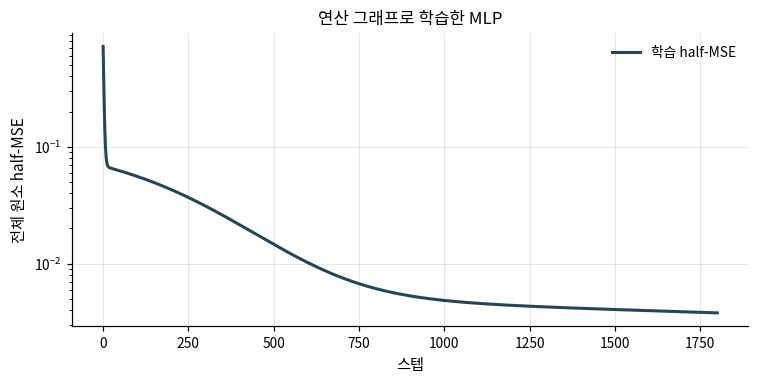

In [14]:
plot_curves(np.arange(len(train_history)), {'학습 half-MSE': train_history}, title='연산 그래프로 학습한 MLP', ylabel='전체 원소 half-MSE', logy=True)

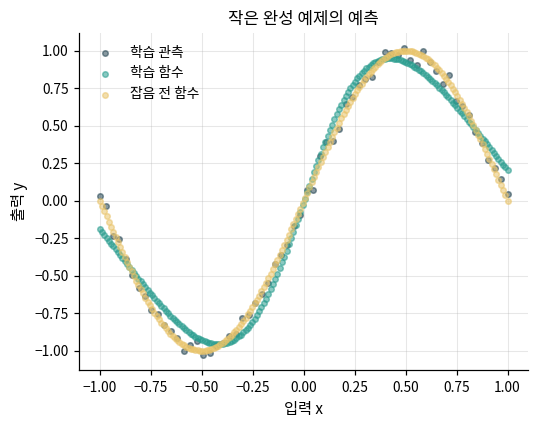

In [15]:
grid = np.linspace(-1, 1, 180)[:, None]
grid_prediction = graph_prediction(grid, trained_parameters).data
plot_clouds([('작은 완성 예제의 예측', {'학습 관측': np.column_stack([X_train, Y_train]),
                                   '학습 함수': np.column_stack([grid, grid_prediction]),
                                   '잡음 전 함수': np.column_stack([grid, np.sin(np.pi*grid)])})],
            xlabel='입력 x', ylabel='출력 y', equal=False)

두 번째 그림은 입력 범위 안의 곡선을 비교합니다. 기울기의 계산을 자동화해도 모델의 구조·손실의 평균 축·학습률은 직접 정합니다.

### stop-gradient를 숫자로 확인하기

$x=3$에서 $x\cdot x$와 $x\cdot\operatorname{stopgrad}(x)$의 값은 모두 9입니다.
앞쪽 경로만 미분하는 두 번째 계산의 기울기는 3이고, 양쪽 경로를 미분하면 6입니다.
이 연산은 표현 예측의 교사 타깃과 RL의 고정 타깃을 만들 때 연결됩니다. 값을 복사해 새 Node로 만드는 것이 이 엔진의 해당 동작입니다.

In [16]:
live = Node(3.)
(live * live).backward()
full_gradient = live.grad.copy()
(live * Node(live.data)).backward()
stopped_gradient = live.grad.copy()
pt = torch.tensor(3., dtype=torch.float64, requires_grad=True)
(pt * pt.detach()).backward()
np.testing.assert_allclose([full_gradient, stopped_gradient, pt.grad.item()], [6., 3., 3.])
print('양쪽 경로 / 한쪽 경로:', full_gradient, stopped_gradient)

양쪽 경로 / 한쪽 경로: 6.0 3.0


## 6. 직접 바꾸기: 새로운 행렬곱을 실제 MLP에 넣기

새 셀에 `my_matmul(a, b)`를 작성해 출력 `Node`를 반환합니다. `a`, `b`는 Node이며,
반환값에 두 부모와 두 입력 기울기를 더하는 `pullback`을 연결합니다.
다음 검사기는 후보를 사각 행렬, 공유 입력, MLP 전체에 실제로 넣습니다.
그 뒤 `fit_graph_mlp(..., matmul_fn=my_matmul, hidden_size=6)`로 너비를 바꾸어 학습해 보세요.

In [17]:
def check_matmul(candidate):
    local_rng = np.random.default_rng(137)
    for N, D, K in [(2, 3, 4), (4, 2, 1)]:
        a, b = Node(local_rng.normal(size=(N, D))), Node(local_rng.normal(size=(D, K)))
        G = local_rng.normal(size=(N, K))
        output = candidate(a, b)
        assert isinstance(output, Node) and output.data.shape == (N, K)
        np.testing.assert_allclose(output.data, a.data @ b.data)
        output.backward(G)
        np.testing.assert_allclose(a.grad, G @ b.data.T, atol=1e-12)
        np.testing.assert_allclose(b.grad, a.data.T @ G, atol=1e-12)
    shared = Node(local_rng.normal(size=(3, 3)))
    G = local_rng.normal(size=(3, 3))
    candidate(shared, shared).backward(G)
    np.testing.assert_allclose(shared.grad, G @ shared.data.T + shared.data.T @ G, atol=1e-12)
    # 서로 다른 두 연산에서 같은 입력을 사용하면 모든 기여를 누적합니다.
    a = Node(local_rng.normal(size=(2, 3)))
    b, c = Node(local_rng.normal(size=(3, 2))), Node(local_rng.normal(size=(3, 2)))
    G = local_rng.normal(size=(2, 2))
    branched = candidate(a, b) + candidate(a, c)
    for _ in range(2):
        branched.backward(G)
        np.testing.assert_allclose(a.grad, G @ (b.data+c.data).T, atol=1e-12)
        np.testing.assert_allclose(b.grad, a.data.T @ G, atol=1e-12)
        np.testing.assert_allclose(c.grad, a.data.T @ G, atol=1e-12)
    # 오른쪽 입력에도 앞선 연산이 있으면 그 부모까지 역전파해야 합니다.
    root_b = Node(local_rng.normal(size=(3, 2)))
    candidate(a, root_b * 2.).backward(G)
    np.testing.assert_allclose(root_b.grad, 2*a.data.T @ G, atol=1e-12)
    X, Y = local_rng.normal(size=(4, 3)), local_rng.normal(size=(4, 2))
    values = [local_rng.normal(size=s) * .2 for s in [(3, 5), (5,), (5, 2), (2,)]]
    params = [Node(value) for value in values]
    loss = graph_loss(X, Y, params, matmul_fn=candidate)
    loss.backward()
    reference_loss, reference_grads = manual_mlp(X, Y, values)
    np.testing.assert_allclose(loss.data, reference_loss, atol=1e-12)
    for p, reference in zip(params, reference_grads):
        np.testing.assert_allclose(p.grad, reference, atol=1e-11)
    return '통과: 사각 행렬·공유 분기·반복 backward·양쪽 부모·MLP 전체 기울기'

In [18]:
print(check_matmul(matmul))
smaller_parameters, smaller_history = fit_graph_mlp(X_train, Y_train, hidden_size=6)
smaller_valid = .5 * np.mean((graph_prediction(X_valid, smaller_parameters).data - Y_valid)**2)
print('hidden=6 학습 / 검증 half-MSE:', smaller_history[-1], smaller_valid)

통과: 사각 행렬·공유 분기·반복 backward·양쪽 부모·MLP 전체 기울기


hidden=6 학습 / 검증 half-MSE: 0.006918263554772796 0.007321249042379014


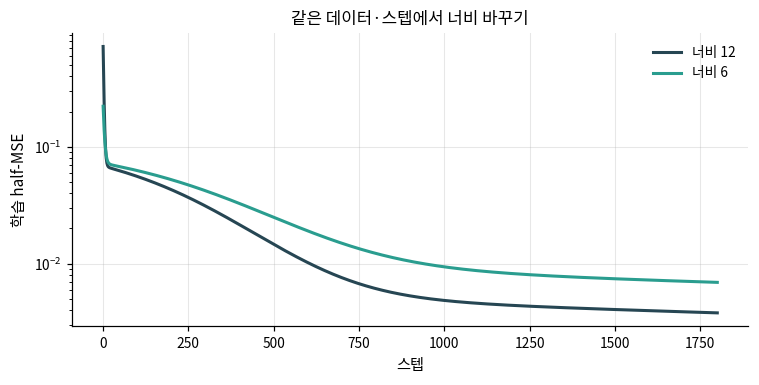

In [19]:
plot_curves(np.arange(len(train_history)), {'너비 12': train_history, '너비 6': smaller_history},
            title='같은 데이터·스텝에서 너비 바꾸기', ylabel='학습 half-MSE', logy=True)

**준비도 확인**

- 공유 Node를 한 번 방문하면서도 여러 경로의 기울기를 합하는 이유를 설명할 수 있나요?
- `sum_to_shape`의 두 종류 합을 각각 작은 배열로 확인할 수 있나요?
- 벡터 출력의 `seed`를 바꾸면 어떤 스칼라 목적의 기울기가 되는지 쓸 수 있나요?
- PyTorch와 이 엔진의 기울기 초기화 위치를 찾고 한 스텝을 대조할 수 있나요?
- 새 연산에 값·부모·VJP를 붙여 전체 MLP 검산까지 통과시킬 수 있나요?

다음 [14 손실·정규화](14_losses_regularization.ipynb)에서는 계산할 목적을 바꿉니다.

공식 API 참고: [PyTorch의 자동미분 안내](https://docs.pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html).
이 노트북의 NumPy 엔진은 본문에 제시한 연산 범위와 초기화 규약을 따릅니다.